In [1]:
import os, sys
from pathlib import Path

REPO_URL  = 'https://github.com/Daniel-Chacha/covid-xray-detection.git'
REPO_ROOT = Path('/kaggle/working/covid-xray-detection')
# DATA_ROOT = Path('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset')
CKPT_ROOT = Path('/kaggle/working/checkpoints')
CACHE_DIR = Path('/kaggle/tmp')          # ~60 GB scratch, not persisted

# Located by structure, not by name. Kaggle nests the mount under
# /kaggle/input/datasets/<owner>/<slug>/, and the inner folder name has changed
# across dataset versions — so find whatever directory contains COVID/images/,
# which is exactly the layout scan_dataset expects.
_found = sorted(Path('/kaggle/input').glob('**/COVID/images'))
assert _found, 'dataset not attached — use "+ Add Input", search covid19-radiography-database'
DATA_ROOT = _found[0].parent.parent



!pip install -q ImageHash
if (REPO_ROOT / '.git').exists():
    !git -C {REPO_ROOT} pull -q
else:
    !git clone -q {REPO_URL} {REPO_ROOT}

sys.path.insert(0, str(REPO_ROOT / 'src'))
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# No %load_ext autoreload: Kaggle's IPython imports `imp` inside that
# extension, and `imp` was removed in Python 3.12, so the magic raises. It is
# not needed here — code arrives by git clone, so a fresh session is current.
# After a mid-session `git pull`, reload explicitly:
#     import importlib, covid_xray.data; importlib.reload(covid_xray.data)
# or restart the kernel.

# Print the commit being run. A stale clone is the standard failure of this
# workflow — edit locally, forget to push, silently run yesterday's code.
!git -C {REPO_ROOT} log -1 --format='running commit %h  %s  (%cr)'
# assert DATA_ROOT.exists(), 'dataset not attached — use "+ Add Input"'
print('DATA_ROOT:', DATA_ROOT)


running commit ad657e8  feat: Grad-CAM with quantified lung attribution ratio, plus training notebook  (19 hours ago)
DATA_ROOT: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset


In [2]:
# !ls -la /kaggle/input
!ls -la /kaggle/input/datasets
print('---')
_found = sorted(Path('/kaggle/input').glob('**/COVID/images'))
assert _found, 'no COVID/images found under /kaggle/input'
DATA_ROOT = _found[0].parent.parent
print('DATA_ROOT:', DATA_ROOT)
print(sorted(p.name for p in DATA_ROOT.iterdir()))


total 12
drwxr-xr-x 3 root root 4096 Aug  1 05:42 .
drwxr-xr-x 3 root root 4096 Aug  1 05:42 ..
drwxr-xr-x 3 root root 4096 Aug  1 05:42 tawsifurrahman
---
DATA_ROOT: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
['COVID', 'COVID.metadata.xlsx', 'Lung_Opacity', 'Lung_Opacity.metadata.xlsx', 'Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Viral Pneumonia', 'Viral Pneumonia.metadata.xlsx']


In [3]:
# 2. Confirm the GPU

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
!nvidia-smi --query-gpu=name,memory.total --format=csv


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [4]:
# 3. Manifests and run the helper

from covid_xray.config import load_config
from covid_xray.splits import load_manifest
from covid_xray.data import build_dataset
from covid_xray.augment import build_augmenter
from covid_xray.train import train_two_stage, enable_mixed_precision

manifests = {s: load_manifest(REPO_ROOT / 'data' / 'splits' / f'{s}.csv')
             for s in ('train', 'val', 'test')}
print({s: len(d) for s, d in manifests.items()})   # expect 14659 / 3141 / 3142

def datasets_for(cfg):
    # Key on variant + size, not run name: raw/masked/lungs_removed produce
    # different pixels, but two runs of the same variant produce identical
    # ones, so they should share rather than each spend a minute re-decoding.
    tag = f'{cfg.variant}_{cfg.image_size}'
    train_ds = build_dataset(manifests['train'], DATA_ROOT, cfg, training=True,
                             augmenter=build_augmenter(cfg),
                             cache_path=str(CACHE_DIR / f'cache_{tag}_train'))
    val_ds = build_dataset(manifests['val'], DATA_ROOT, cfg, training=False,
                           cache_path=str(CACHE_DIR / f'cache_{tag}_val'))
    return train_ds, val_ds


def run_densenet(config_name):
    cfg = load_config(REPO_ROOT / 'configs' / f'{config_name}.yaml')
    enable_mixed_precision(cfg)
    return train_two_stage(cfg, *datasets_for(cfg), CKPT_ROOT)


{'train': 14659, 'val': 3141, 'test': 3142}


I0000 00:00:1785563172.245622      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785563172.248499      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


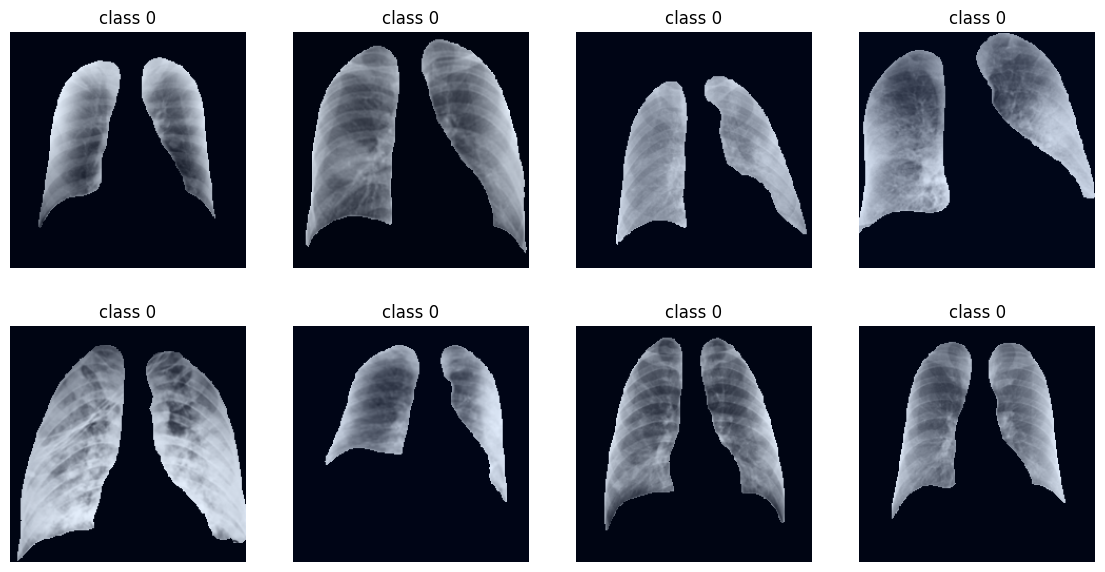

In [5]:
import numpy as np
import matplotlib.pyplot as plt

cfg_check = load_config(REPO_ROOT / 'configs' / 'run2_masked.yaml')
check_ds = build_dataset(manifests['val'].head(8), DATA_ROOT, cfg_check, training=False)
images, labels = next(iter(check_ds))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, image, label in zip(axes.ravel(), images.numpy(), labels.numpy()):
    shown = (image - image.min()) / (np.ptp(image) + 1e-8)
    ax.imshow(shown); ax.set_title(f'class {label.argmax()}'); ax.axis('off')
plt.show()


In [6]:
# # 5. One epoch smoke test

# from covid_xray.config import RunConfig
# from covid_xray.train import set_global_seed

# smoke = RunConfig(name='smoke', variant='raw', model='densenet121',
#                   stage_a_epochs=1, stage_b_epochs=1, mixed_precision=True)
# enable_mixed_precision(smoke)
# _, smoke_history = train_two_stage(smoke, *datasets_for(smoke), CKPT_ROOT)
# print('smoke val macro-F1:', smoke_history['stage_b']['val_macro_f1'])


In [7]:
# 6.

model1, history1 = run_densenet('run1_raw')
print('run1 best val macro-F1:', max(history1['stage_b']['val_macro_f1']))


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
  3/459 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.3733 - loss: 1.4129 - macro_f1: 0.1490   

I0000 00:00:1785563220.211540     148 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6657 - loss: 0.7257 - macro_f1: 0.4903
Epoch 1: val_macro_f1 improved from None to 0.63946, saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 167s 276ms/step - accuracy: 0.7252 - loss: 0.6403 - macro_f1: 0.6920 - val_accuracy: 0.7208 - val_loss: 0.7630 - val_macro_f1: 0.6395
Epoch 2/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7673 - loss: 0.5728 - macro_f1: 0.5750
Epoch 2: val_macro_f1 improved from 0.63946 to 0.68593, saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/run1_raw_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - accuracy: 0.7893 - loss: 0.4989 - macro_f1: 0.7664 - val_accuracy: 0.7440 - val_loss: 0.7175 - val_macro_f1: 0.6859
Epoch 3/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accurac

In [8]:
# 7. 

model2, history2 = run_densenet('run2_masked')
print('run2 best val macro-F1:', max(history2['stage_b']['val_macro_f1']))


Epoch 1/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6252 - loss: 0.8269 - macro_f1: 0.4610
Epoch 1: val_macro_f1 improved from None to 0.55402, saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 171s 284ms/step - accuracy: 0.7005 - loss: 0.7187 - macro_f1: 0.6521 - val_accuracy: 0.6638 - val_loss: 0.8437 - val_macro_f1: 0.5540
Epoch 2/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7130 - loss: 0.6743 - macro_f1: 0.5369
Epoch 2: val_macro_f1 improved from 0.55402 to 0.58263, saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/run2_masked_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 61s 132ms/step - accuracy: 0.7670 - loss: 0.5504 - macro_f1: 0.7337 - val_accuracy: 0.6670 - val_loss: 0.8344 - val_macro_f1: 0.5826
Epoch 3/8
458/459 ━━━━━━━━━━━━━━━━━━━━ 0

In [9]:
# 8 .

model4, history4 = run_densenet('run4_lungs_removed')
print('run4 best val macro-F1:', max(history4['stage_b']['val_macro_f1']))


Epoch 1/8
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6164 - loss: 0.8032 - macro_f1: 0.4468
Epoch 1: val_macro_f1 improved from None to 0.55115, saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 149s 251ms/step - accuracy: 0.6642 - loss: 0.7363 - macro_f1: 0.6311 - val_accuracy: 0.6613 - val_loss: 0.8800 - val_macro_f1: 0.5511
Epoch 2/8
457/459 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7087 - loss: 0.6550 - macro_f1: 0.5326
Epoch 2: val_macro_f1 improved from 0.55115 to 0.58555, saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/run4_lungs_removed_stagea.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 60s 130ms/step - accuracy: 0.7416 - loss: 0.5699 - macro_f1: 0.7240 - val_accuracy: 0.6858 - val_loss: 0.8118 - val_macro_f1: 0.5855
Epoch 3/8
45

In [10]:
# 9. The 8x8 liner probe(~2min)

import joblib
from sklearn.metrics import f1_score
from covid_xray.data import extract_downsampled_features
from covid_xray.models import build_probe

X_train, y_train = extract_downsampled_features(manifests['train'], DATA_ROOT, size=8)
X_val,   y_val   = extract_downsampled_features(manifests['val'],   DATA_ROOT, size=8)

probe = build_probe(seed=42).fit(X_train, y_train)
print('probe val macro-F1:', f1_score(y_val, probe.predict(X_val), average='macro'))

# joblib is pickle-based and executes code on load. Safe here: written and read
# only by this project. Never load a .joblib you did not produce yourself.
joblib.dump(probe, CKPT_ROOT / 'run3_probe8.joblib')


probe val macro-F1: 0.6466608991564624


['/kaggle/working/checkpoints/run3_probe8.joblib']

In [11]:
# 10. Verify and persist

import json, glob
for path in sorted(glob.glob(str(CKPT_ROOT / '*_history.json'))):
    payload = json.load(open(path))
    best = max(payload['history']['stage_b']['val_macro_f1'])
    print(f"{payload['config']['name']:22s} best val macro-F1 = {best:.4f}")
!ls -la {CKPT_ROOT}


run1_raw               best val macro-F1 = 0.8507
run2_masked            best val macro-F1 = 0.7217
run4_lungs_removed     best val macro-F1 = 0.8274
total 461568
drwxr-xr-x 2 root root     4096 Aug  1 06:57 .
drwxr-xr-x 6 root root     4096 Aug  1 05:52 ..
-rw-r--r-- 1 root root 63881362 Aug  1 06:12 run1_raw_final.keras
-rw-r--r-- 1 root root     4671 Aug  1 06:12 run1_raw_history.json
-rw-r--r-- 1 root root      999 Aug  1 05:56 run1_raw_stagea.csv
-rw-r--r-- 1 root root 29757100 Aug  1 05:54 run1_raw_stagea.keras
-rw-r--r-- 1 root root     1829 Aug  1 06:12 run1_raw_stageb.csv
-rw-r--r-- 1 root root 63881362 Aug  1 06:09 run1_raw_stageb.keras
-rw-r--r-- 1 root root 63881371 Aug  1 06:32 run2_masked_final.keras
-rw-r--r-- 1 root root     3494 Aug  1 06:32 run2_masked_history.json
-rw-r--r-- 1 root root      995 Aug  1 06:22 run2_masked_stagea.csv
-rw-r--r-- 1 root root 29757109 Aug  1 06:21 run2_masked_stagea.keras
-rw-r--r-- 1 root root     1002 Aug  1 06:32 run2_masked_stageb.csv


In [12]:
from pathlib import Path
import numpy as np, joblib
from tensorflow import keras

CKPT_ROOT = Path('/kaggle/working/checkpoints')
EXPECTED = ['run1_raw_final.keras', 'run2_masked_final.keras',
            'run4_lungs_removed_final.keras', 'run3_probe8.joblib']

for name in EXPECTED:
    path = CKPT_ROOT / name
    if not path.exists():
        print(f'MISSING   {name}')
        continue
    mb = path.stat().st_size / 1e6
    try:
        if path.suffix == '.keras':
            model = keras.models.load_model(path)
            detail = f'output {model.output_shape}'
            del model
        else:
            probe = joblib.load(path)
            detail = f'predict_proba {probe.predict_proba(np.zeros((1, 64))).shape}'
        print(f'OK        {mb:7.1f} MB  {name}  ->  {detail}')
    except Exception as exc:
        print(f'CORRUPT   {name}: {type(exc).__name__}: {exc}')

total = sum(f.stat().st_size for f in Path('/kaggle/working').rglob('*') if f.is_file())
print(f'\n/kaggle/working total: {total/1e6:.0f} MB  (limit 20,000 MB)')


OK           63.9 MB  run1_raw_final.keras  ->  output (None, 4)
OK           63.9 MB  run2_masked_final.keras  ->  output (None, 4)
OK           63.9 MB  run4_lungs_removed_final.keras  ->  output (None, 4)
OK            0.0 MB  run3_probe8.joblib  ->  predict_proba (1, 4)

/kaggle/working total: 482 MB  (limit 20,000 MB)


In [13]:
from pathlib import Path
import json, glob
CKPT = Path('/kaggle/working/checkpoints')
for path in sorted(glob.glob(str(CKPT / '*_history.json'))):
    payload = json.load(open(path))
    print(f"{payload['config']['name']:22s} best val macro-F1 = "
          f"{max(payload['history']['stage_b']['val_macro_f1']):.4f}")
for f in sorted(CKPT.glob('*final*')) + sorted(CKPT.glob('*.joblib')):
    print(f'{f.stat().st_size/1e6:7.1f} MB  {f.name}')


run1_raw               best val macro-F1 = 0.8507
run2_masked            best val macro-F1 = 0.7217
run4_lungs_removed     best val macro-F1 = 0.8274
   63.9 MB  run1_raw_final.keras
   63.9 MB  run2_masked_final.keras
   63.9 MB  run4_lungs_removed_final.keras
    0.0 MB  run3_probe8.joblib


In [14]:
# --- Task 11: test-set evaluation, run in-session ---------------------------
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
from tensorflow import keras

from covid_xray.config import CLASS_NAMES
from covid_xray.evaluate import predict_probabilities, summarise_run

# Checkpoints are right here — no /kaggle/input round-trip needed.
CKPT_ROOT = Path('/kaggle/working/checkpoints')
REPORTS   = REPO_ROOT / 'reports'
(REPORTS / 'figures').mkdir(parents=True, exist_ok=True)

test_manifest = load_manifest(REPO_ROOT / 'data' / 'splits' / 'test.csv')
y_true = test_manifest['label'].to_numpy()
print(len(test_manifest), dict(test_manifest['class_name'].value_counts()))


3142 {'Normal': np.int64(1529), 'Lung_Opacity': np.int64(902), 'COVID': np.int64(511), 'Viral Pneumonia': np.int64(200)}


In [15]:
predictions = {}
for config_name in ('run1_raw', 'run2_masked', 'run4_lungs_removed'):
    cfg = load_config(REPO_ROOT / 'configs' / f'{config_name}.yaml')
    model = keras.models.load_model(CKPT_ROOT / f'{cfg.name}_final.keras')
    predictions[config_name] = predict_probabilities(
        model, build_dataset(test_manifest, DATA_ROOT, cfg, training=False))
    print(config_name, predictions[config_name].shape)
    del model
    
probe = joblib.load(CKPT_ROOT / 'run3_probe8.joblib')
X_test, _ = extract_downsampled_features(test_manifest, DATA_ROOT, size=8)
predictions['run3_probe8'] = probe.predict_proba(X_test)
print('run3_probe8', predictions['run3_probe8'].shape)


run1_raw (3142, 4)
run2_masked (3142, 4)
run4_lungs_removed (3142, 4)
run3_probe8 (3142, 4)


In [16]:
    # 4. Results table

ORDER = ('run1_raw', 'run2_masked', 'run3_probe8', 'run4_lungs_removed')
summaries = {name: summarise_run(name, y_true, predictions[name]) for name in ORDER}

table = pd.DataFrame([{
    'run': s['run'],
    'macro_F1': round(s['macro_f1'], 4),
    'macro_F1_95CI': f"[{s['macro_f1_ci'][0]:.3f}, {s['macro_f1_ci'][1]:.3f}]",
    'COVID_sens': round(s['covid_sensitivity'], 4),
    'COVID_spec': round(s['covid_specificity'], 4),
    'COVID_spec@95sens': round(s['covid_specificity_at_95_sensitivity'], 4),
    'ECE': round(s['ece'], 4),
    'pair_acc': round(s['restricted_pair']['accuracy'], 4),
    'pair_AUC': round(s['restricted_pair']['roc_auc'], 4),
} for s in summaries.values()]).set_index('run')

(REPO_ROOT / 'reports').mkdir(exist_ok=True)
table.to_csv(REPO_ROOT / 'reports' / 'results.csv')
table


,macro_F1,macro_F1_95CI,COVID_sens,COVID_spec,COVID_spec@95sens,ECE,pair_acc,pair_AUC
run,,,,,,,,
run1_raw,0.8523,"[0.839, 0.866]",0.6380,0.9958,0.8917,0.0352,0.9222,0.9797
run2_masked,0.7228,"[0.704, 0.741]",0.4853,0.9552,0.5181,0.0454,0.7870,0.8916
run3_probe8,0.6417,"[0.622, 0.660]",0.5519,0.8362,0.3071,0.0216,0.7403,0.8102
run4_lungs_removed,0.8288,"[0.813, 0.844]",0.6204,0.9932,0.8985,0.0112,0.9137,0.9815


In [17]:
# 5. Per class detail
for name in ORDER:
    print(f'\n=== {name} ===')
    print(summaries[name]['per_class'].round(4))



=== run1_raw ===
                 precision  recall      f1  support  roc_auc  pr_auc
COVID               0.9674  0.6380  0.7689      511   0.9803  0.9322
Lung_Opacity        0.8825  0.7993  0.8389      902   0.9637  0.9288
Normal              0.8296  0.9555  0.8881     1529   0.9646  0.9578
Viral Pneumonia     0.8590  0.9750  0.9133      200   0.9983  0.9793

=== run2_masked ===
                 precision  recall      f1  support  roc_auc  pr_auc
COVID               0.6776  0.4853  0.5656      511   0.8873  0.6847
Lung_Opacity        0.9013  0.6075  0.7258      902   0.9349  0.8673
Normal              0.7651  0.9307  0.8398     1529   0.9293  0.9152
Viral Pneumonia     0.6266  0.9650  0.7598      200   0.9936  0.9432

=== run3_probe8 ===
                 precision  recall      f1  support  roc_auc  pr_auc
COVID               0.3955  0.5519  0.4608      511   0.7876  0.4738
Lung_Opacity        0.6755  0.6530  0.6640      902   0.8648  0.6972
Normal              0.8148  0.6645  0.7320 

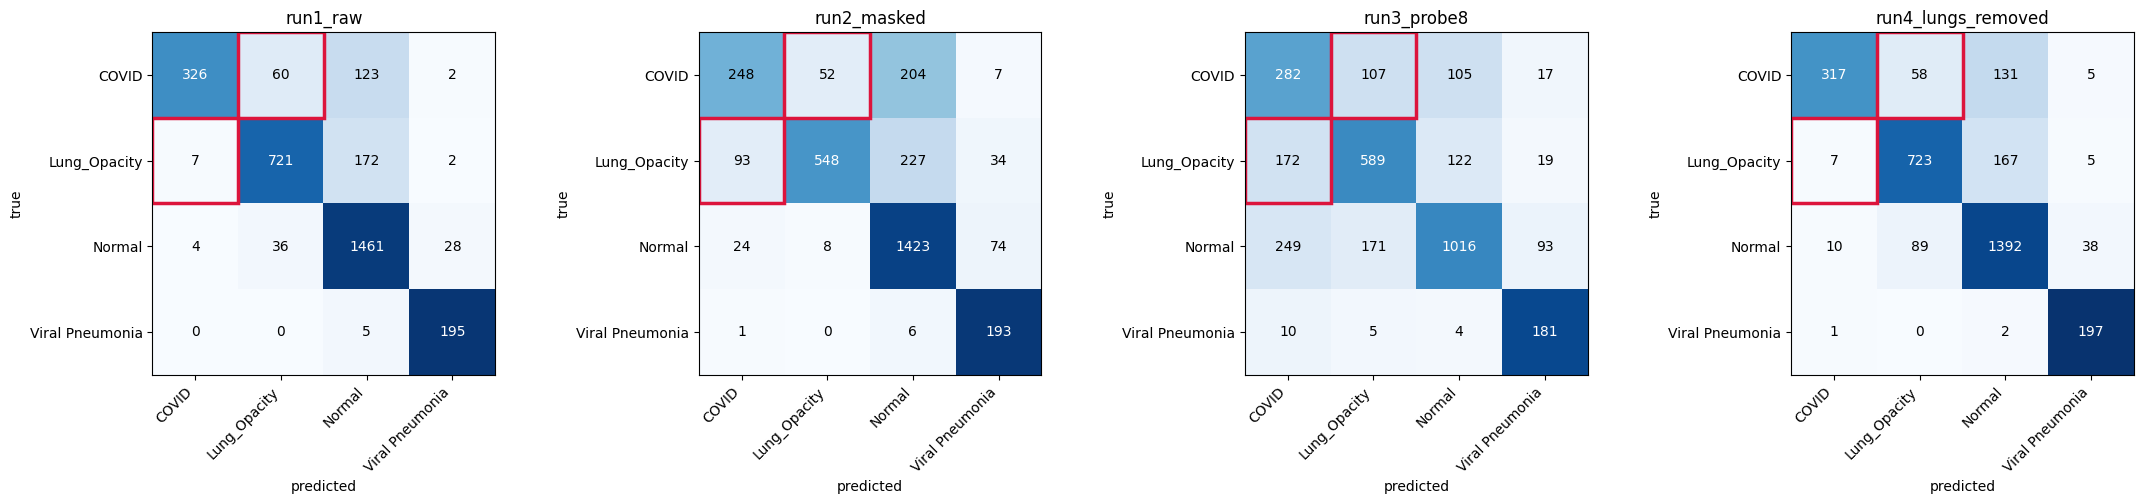

In [19]:
# 6. Confusion matrices, COVID<->Lung Opacity highlighted
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, ORDER):
    matrix = summaries[name]['confusion']
    normalised = matrix.div(matrix.sum(axis=1).clip(lower=1), axis=0)
    ax.imshow(normalised, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(4), CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(4), CLASS_NAMES)
    ax.set_title(name); ax.set_xlabel('predicted'); ax.set_ylabel('true')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{matrix.iloc[i, j]}', ha='center', va='center',
                    color='white' if normalised.iloc[i, j] > 0.5 else 'black')
    for i, j in ((0, 1), (1, 0)):   # the two cells that carry the audit
        ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor='crimson', lw=2.5))
plt.tight_layout()
(REPO_ROOT / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)
plt.savefig(REPO_ROOT / 'reports' / 'figures' / 'confusion_all_runs.png', dpi=150)
plt.show()


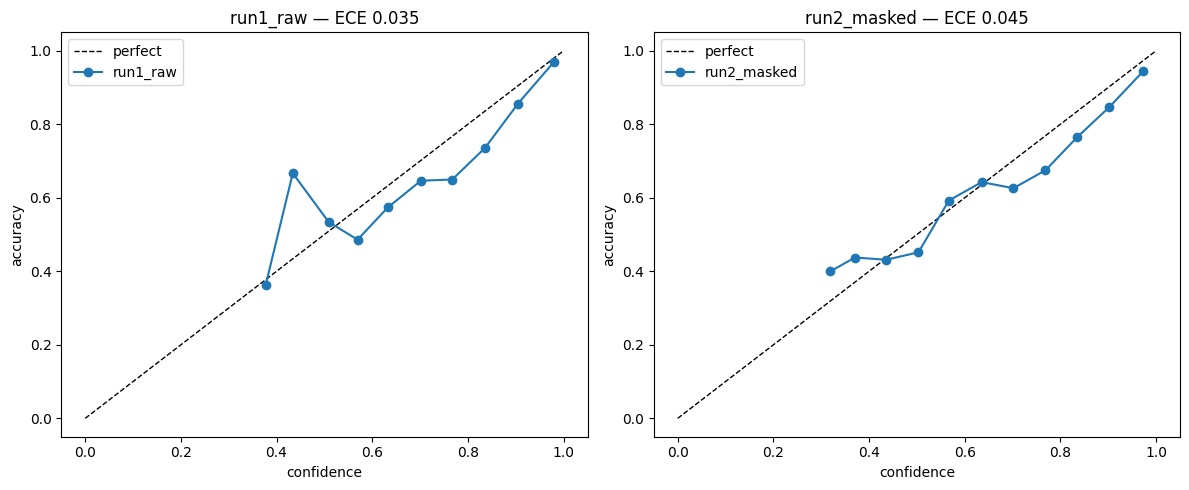

In [20]:
# 7. Calibration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ('run1_raw', 'run2_masked')):
    probs = predictions[name]
    confidence, correct = probs.max(axis=1), (probs.argmax(axis=1) == y_true).astype(float)
    edges = np.linspace(0, 1, 16)
    xs, ys = [], []
    for low, high in zip(edges[:-1], edges[1:]):
        in_bin = (confidence > low) & (confidence <= high)
        if in_bin.sum() >= 5:
            xs.append(confidence[in_bin].mean()); ys.append(correct[in_bin].mean())
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect')
    ax.plot(xs, ys, 'o-', label=name)
    ax.set_xlabel('confidence'); ax.set_ylabel('accuracy')
    ax.set_title(f"{name} — ECE {summaries[name]['ece']:.3f}"); ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / 'reports' / 'figures' / 'calibration.png', dpi=150)
plt.show()


In [21]:
# 8. Persist Everything

serialisable = {}
for name, summary in summaries.items():
    payload = {k: v for k, v in summary.items() if k not in ('per_class', 'confusion')}
    payload['restricted_pair'] = {**summary['restricted_pair'],
                                  'pair': list(summary['restricted_pair']['pair'])}
    payload['per_class'] = summary['per_class'].round(4).to_dict()
    payload['confusion'] = summary['confusion'].to_dict()
    serialisable[name] = payload
    
with open(REPO_ROOT / 'reports' / 'results.json', 'w') as handle:
    json.dump(serialisable, handle, indent=2, default=float)

# Keep predictions — Task 13's failure gallery needs run1's probabilities.
np.save(REPO_ROOT / 'reports' / 'run1_raw_test_probs.npy', predictions['run1_raw'])
print('written')


written


In [22]:
# --- Package every artefact worth keeping into one downloadable zip --------
import shutil
from pathlib import Path
from IPython.display import FileLink, display

STAGE   = Path('/kaggle/working/_deliverables')
ARCHIVE = '/kaggle/working/covid_xray_artifacts'      # .zip appended by make_archive
REPORTS = REPO_ROOT / 'reports'

shutil.rmtree(STAGE, ignore_errors=True)
STAGE.mkdir(parents=True)

# Globs rather than a fixed list, so this also picks up Task 13's outputs
# when you re-run it later.
SOURCES = [
    (REPORTS,              '*.csv',            'reports'),
    (REPORTS,              '*.json',           'reports'),
    (REPORTS,              '*.npy',            'reports'),
    (REPORTS / 'figures',  '*.png',            'reports/figures'),
    (CKPT_ROOT,            '*_history.json',   'checkpoints'),
    (CKPT_ROOT,            '*_stage*.csv',     'checkpoints'),
]

total = 0
for folder, pattern, destination in SOURCES:
    if not folder.exists():
        print(f'(skip, missing) {folder}')
        continue
    for src in sorted(folder.glob(pattern)):
        dst = STAGE / destination / src.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        size = src.stat().st_size
        total += size
        print(f'{size/1024:9.1f} KB  {destination}/{src.name}')

if total == 0:
    raise SystemExit('nothing staged — has Cell 8 run yet?')

archive = shutil.make_archive(ARCHIVE, 'zip', STAGE)
print(f'\n{Path(archive).stat().st_size/1024:.1f} KB total  ->  {archive}')
display(FileLink(Path(archive).name))


      0.1 KB  reports/class_distribution.csv
     27.1 KB  reports/duplicates.csv
      0.4 KB  reports/results.csv
      7.9 KB  reports/results.json
     98.3 KB  reports/run1_raw_test_probs.npy
     83.7 KB  reports/figures/calibration.png
     36.1 KB  reports/figures/class_distribution.png
    105.4 KB  reports/figures/confusion_all_runs.png
      4.6 KB  checkpoints/run1_raw_history.json
      3.4 KB  checkpoints/run2_masked_history.json
      4.4 KB  checkpoints/run4_lungs_removed_history.json
      1.0 KB  checkpoints/run1_raw_stagea.csv
      1.8 KB  checkpoints/run1_raw_stageb.csv
      1.0 KB  checkpoints/run2_masked_stagea.csv
      1.0 KB  checkpoints/run2_masked_stageb.csv
      0.9 KB  checkpoints/run4_lungs_removed_stagea.csv
      1.8 KB  checkpoints/run4_lungs_removed_stageb.csv

266.2 KB total  ->  /kaggle/working/covid_xray_artifacts.zip


/kaggle/working/covid_xray_artifacts.zip

In [23]:
# --- Task 13: Grad-CAM audit -----------------------------------------------
from PIL import Image
from covid_xray.gradcam import grad_cam, lung_attribution_ratio
from covid_xray.models import split_feature_and_head

AUDIT_RUNS = ('run1_raw', 'run2_masked')
test_manifest = test_manifest.reset_index(drop=True)

def attribution_ratios(config_name):
    """Fraction of Grad-CAM mass inside the lung mask, per test image."""
    cfg = load_config(REPO_ROOT / 'configs' / f'{config_name}.yaml')
    model = keras.models.load_model(CKPT_ROOT / f'{cfg.name}_final.keras')
    # Build the feature/head split once: rebuilding it per batch traverses
    # 427 layers each time.
    split = split_feature_and_head(model)
    ds = build_dataset(test_manifest, DATA_ROOT, cfg, training=False)

    ratios, position = [], 0
    for images, _ in ds:
        for heatmap in grad_cam(model, images, split=split):
            mask = np.asarray(Image.open(DATA_ROOT / test_manifest.iloc[position]['mask_path']))
            ratios.append(lung_attribution_ratio(heatmap, mask))
            position += 1
    del model
    keras.backend.clear_session()
    return np.array(ratios)

ratio_frame = test_manifest[['path', 'class_name', 'label']].copy()
for name in AUDIT_RUNS:
    ratio_frame[name] = attribution_ratios(name)
    print(f'{name}: done')

ratio_frame.to_csv(REPORTS / 'attribution_ratios.csv', index=False)
ratio_frame.head()


run1_raw: done


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 70 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


run2_masked: done


,path,class_name,label,run1_raw,run2_masked
0,COVID/images/COVID-10.png,COVID,0,0.432886,0.325179
1,COVID/images/COVID-1001.png,COVID,0,0.043872,0.176819
2,COVID/images/COVID-1012.png,COVID,0,0.124285,0.474929
3,COVID/images/COVID-1015.png,COVID,0,0.380677,0.440025
4,COVID/images/COVID-1029.png,COVID,0,0.323585,0.462155


In [24]:
# 2.the headline audit number

def mean_ci(values, seed=42, n=2000):
    values = values[~np.isnan(values)]
    rng = np.random.default_rng(seed)
    draws = [values[rng.integers(0, len(values), len(values))].mean() for _ in range(n)]
    return values.mean(), np.quantile(draws, 0.025), np.quantile(draws, 0.975)

for name in AUDIT_RUNS:
    values = ratio_frame[name].to_numpy()
    mean, low, high = mean_ci(values)
    n_nan = int(np.isnan(values).sum())
    print(f'{name:14s} lung attribution ratio = {mean:.3f}  95% CI [{low:.3f}, {high:.3f}]'
          f'   (degenerate maps: {n_nan})')


run1_raw       lung attribution ratio = 0.314  95% CI [0.311, 0.318]   (degenerate maps: 5)
run2_masked    lung attribution ratio = 0.376  95% CI [0.373, 0.380]   (degenerate maps: 0)


                run1_raw       run2_masked      
                    mean count        mean count
class_name                                      
COVID              0.288   511       0.376   511
Lung_Opacity       0.260   902       0.337   902
Normal             0.356  1529       0.401  1529
Viral Pneumonia    0.309   195       0.367   200


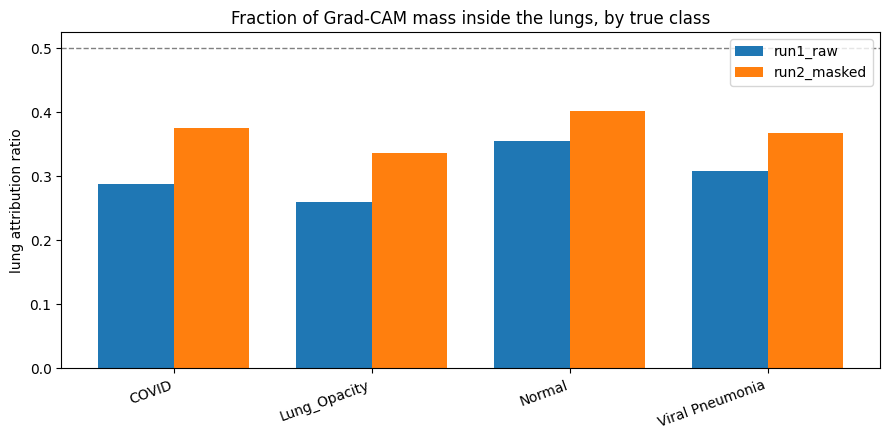

In [25]:
# 3. attribution by class

print(ratio_frame.groupby('class_name')[list(AUDIT_RUNS)].agg(['mean', 'count']).round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
positions, width = np.arange(len(CLASS_NAMES)), 0.38
for offset, name in zip((-width/2, width/2), AUDIT_RUNS):
    means = [ratio_frame.loc[ratio_frame.class_name == c, name].mean() for c in CLASS_NAMES]
    ax.bar(positions + offset, means, width, label=name)
ax.set_xticks(positions, CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('lung attribution ratio'); ax.axhline(0.5, ls='--', c='grey', lw=1)
ax.set_title('Fraction of Grad-CAM mass inside the lungs, by true class'); ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'figures' / 'attribution_by_class.png', dpi=150)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 70 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


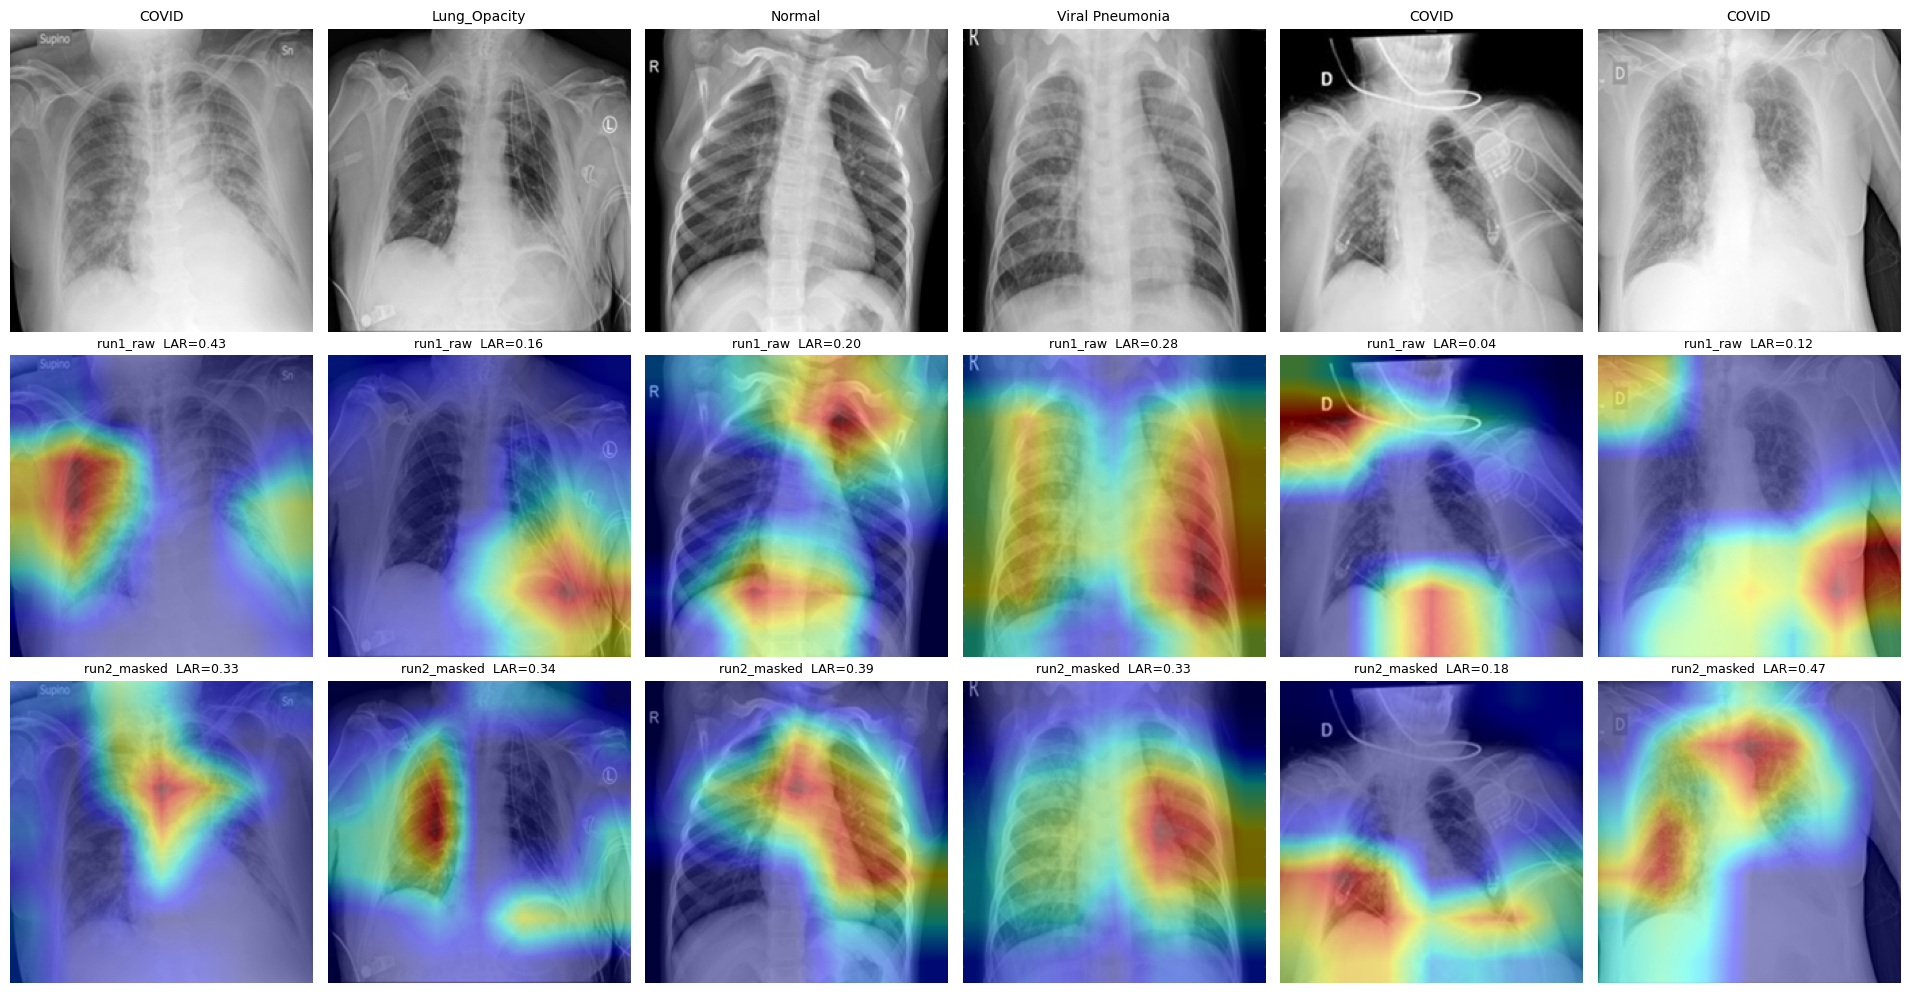

In [26]:
# 4. qualitative panel

picks = pd.concat(
    [test_manifest[test_manifest.class_name == c].head(1) for c in CLASS_NAMES]
    + [test_manifest[test_manifest.class_name == 'COVID'].iloc[1:3]]
).reset_index(drop=True)

heat = {}
for name in AUDIT_RUNS:
    cfg = load_config(REPO_ROOT / 'configs' / f'{name}.yaml')
    model = keras.models.load_model(CKPT_ROOT / f'{cfg.name}_final.keras')
    images, _ = next(iter(build_dataset(picks, DATA_ROOT, cfg, training=False)))
    heat[name] = grad_cam(model, images, split=split_feature_and_head(model))
    del model; keras.backend.clear_session()

fig, axes = plt.subplots(3, len(picks), figsize=(3.2 * len(picks), 10))
for column, (_, row) in enumerate(picks.iterrows()):
    original = np.asarray(Image.open(DATA_ROOT / row['path']).convert('L').resize((224, 224)))
    mask = np.asarray(Image.open(DATA_ROOT / row['mask_path']))
    axes[0, column].imshow(original, cmap='gray')
    axes[0, column].set_title(row['class_name'], fontsize=10)
    for offset, name in enumerate(AUDIT_RUNS, start=1):
        lar = lung_attribution_ratio(heat[name][column], mask)
        axes[offset, column].imshow(original, cmap='gray')
        axes[offset, column].imshow(heat[name][column], cmap='jet', alpha=0.45)
        axes[offset, column].set_title(f'{name}  LAR={lar:.2f}', fontsize=9)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(REPORTS / 'figures' / 'gradcam_panel.png', dpi=150)
plt.show()


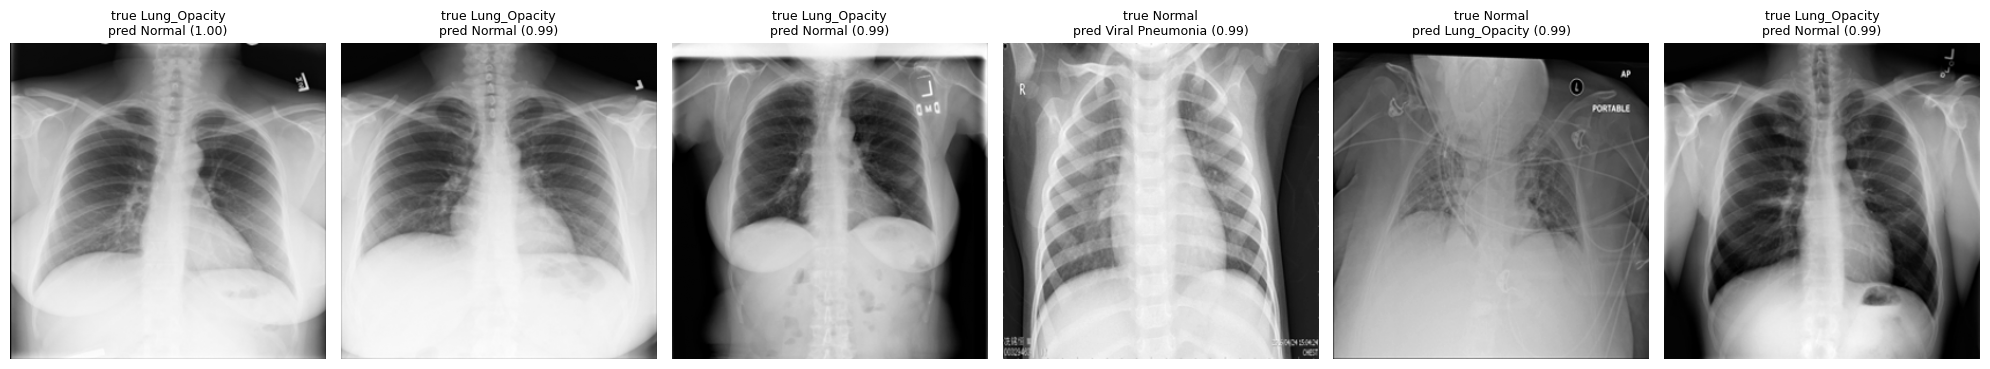

In [27]:
# 5. Failure Gallery

probabilities = predictions['run1_raw']
y_pred, confidence = probabilities.argmax(axis=1), probabilities.max(axis=1)
wrong = np.nonzero(y_pred != y_true)[0]
worst = wrong[np.argsort(-confidence[wrong])][:6]

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, index in zip(axes, worst):
    row = test_manifest.iloc[index]
    ax.imshow(np.asarray(Image.open(DATA_ROOT / row['path']).convert('L')), cmap='gray')
    ax.set_title(f'true {CLASS_NAMES[y_true[index]]}\n'
                 f'pred {CLASS_NAMES[y_pred[index]]} ({confidence[index]:.2f})', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(REPORTS / 'figures' / 'failure_gallery.png', dpi=150)
plt.show()


In [28]:
# 6. Re-zip and download

# --- Package every artefact worth keeping into one downloadable zip --------
import shutil
from pathlib import Path
from IPython.display import FileLink, display

STAGE   = Path('/kaggle/working/_deliverables')
ARCHIVE = '/kaggle/working/covid_xray_artifacts'      # .zip appended by make_archive
REPORTS = REPO_ROOT / 'reports'

shutil.rmtree(STAGE, ignore_errors=True)
STAGE.mkdir(parents=True)

# Globs rather than a fixed list, so this also picks up Task 13's outputs
# when you re-run it later.
SOURCES = [
    (REPORTS,              '*.csv',            'reports'),
    (REPORTS,              '*.json',           'reports'),
    (REPORTS,              '*.npy',            'reports'),
    (REPORTS / 'figures',  '*.png',            'reports/figures'),
    (CKPT_ROOT,            '*_history.json',   'checkpoints'),
    (CKPT_ROOT,            '*_stage*.csv',     'checkpoints'),
]

total = 0
for folder, pattern, destination in SOURCES:
    if not folder.exists():
        print(f'(skip, missing) {folder}')
        continue
    for src in sorted(folder.glob(pattern)):
        dst = STAGE / destination / src.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        size = src.stat().st_size
        total += size
        print(f'{size/1024:9.1f} KB  {destination}/{src.name}')

if total == 0:
    raise SystemExit('nothing staged — has Cell 8 run yet?')

archive = shutil.make_archive(ARCHIVE, 'zip', STAGE)
print(f'\n{Path(archive).stat().st_size/1024:.1f} KB total  ->  {archive}')
display(FileLink(Path(archive).name))


    257.9 KB  reports/attribution_ratios.csv
      0.1 KB  reports/class_distribution.csv
     27.1 KB  reports/duplicates.csv
      0.4 KB  reports/results.csv
      7.9 KB  reports/results.json
     98.3 KB  reports/run1_raw_test_probs.npy
     50.0 KB  reports/figures/attribution_by_class.png
     83.7 KB  reports/figures/calibration.png
     36.1 KB  reports/figures/class_distribution.png
    105.4 KB  reports/figures/confusion_all_runs.png
    679.1 KB  reports/figures/failure_gallery.png
   2801.2 KB  reports/figures/gradcam_panel.png
      4.6 KB  checkpoints/run1_raw_history.json
      3.4 KB  checkpoints/run2_masked_history.json
      4.4 KB  checkpoints/run4_lungs_removed_history.json
      1.0 KB  checkpoints/run1_raw_stagea.csv
      1.8 KB  checkpoints/run1_raw_stageb.csv
      1.0 KB  checkpoints/run2_masked_stagea.csv
      1.0 KB  checkpoints/run2_masked_stageb.csv
      0.9 KB  checkpoints/run4_lungs_removed_stagea.csv
      1.8 KB  checkpoints/run4_lungs_removed_stage

/kaggle/working/covid_xray_artifacts.zip

In [29]:
coverage = []
for path in test_manifest['mask_path']:
    m = np.asarray(Image.open(DATA_ROOT / path))
    if m.ndim == 3:
        m = m[..., 0]
    coverage.append((m > 127).mean())
coverage = np.array(coverage)
print(f'mean lung mask coverage = {coverage.mean():.3f}  '
      f'(this is the LAR of a uniform attribution map)')


mean lung mask coverage = 0.238  (this is the LAR of a uniform attribution map)
